# L&T EduTech – Task 5
## Object Detection and Image Segmentation

**Objective:** Develop computer vision systems for object detection and semantic image segmentation.

### Practical components
1. YOLO object detection on a construction PPE dataset
2. Faster R-CNN object detection on a road-sign dataset
3. U-Net semantic segmentation on the Oxford-IIIT Pet dataset
4. Object-detection evaluation using mAP
5. Segmentation evaluation using IoU and Dice Score
6. Prediction visualizations
7. Comparative analysis and observations

> **Note:** This notebook is designed for Google Colab. GPU is recommended for YOLO, Faster R-CNN and U-Net training.

## 1. Setup and Installation

Run this cell first. It installs the packages used by all three practical sections.

In [24]:
!pip -q install ultralytics torchmetrics pycocotools tensorflow-datasets importlib_resources

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.2 MB/s eta 0:00:00


In [25]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# PART A — YOLO Object Detection

The existing practical direction uses the construction PPE dataset. YOLO is used to detect objects such as safety equipment in images.

The section produces:
- trained YOLO model
- validation metrics
- mAP@50
- mAP@50:95
- prediction images

In [26]:
from ultralytics import YOLO
import os, shutil, urllib.request, zipfile

# Download the same construction-PPE data source used by the uploaded YOLO practical.
IMAGE_DIR = "/content/ppe_raw_images"
ZIP_PATH = "/content/construction_ppe_real.zip"

if not os.path.exists("/content/construction-ppe.yaml"):
    url = "https://github.com/ultralytics/assets/releases/download/v8.3.0/construction-ppe.zip"
    try:
        urllib.request.urlretrieve(url, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall("/content")
    except Exception as e:
        print("Dataset download did not complete:", e)

print("Contents:", os.listdir("/content")[:20])

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Dataset download did not complete: HTTP Error 404: Not Found
Contents: ['.config', 'road_signs', 'LT_Task5_outputs', 'sample_data']


In [27]:
# Locate the YAML file automatically so the notebook is less dependent on folder names.
yaml_candidates = []
for root, dirs, files in os.walk("/content"):
    for f in files:
        if f.endswith(".yaml") and ("ppe" in f.lower() or "construction" in f.lower()):
            yaml_candidates.append(os.path.join(root, f))

print("YAML candidates:", yaml_candidates[:10])

if yaml_candidates:
    YOLO_DATA = yaml_candidates[0]
else:
    YOLO_DATA = "/content/construction-ppe.yaml"

print("YOLO dataset config:", YOLO_DATA)

YAML candidates: []
YOLO dataset config: /content/construction-ppe.yaml


### YOLO training

A lightweight YOLO model is used so that the practical remains realistic for Colab. Increase epochs if more training time/GPU memory is available.

In [ ]:
yolo_model = YOLO("yolo11n.pt")

try:
    yolo_train = yolo_model.train(
        data=YOLO_DATA,
        epochs=10,
        imgsz=640,
        batch=16,
        device=0 if tf.config.list_physical_devices("GPU") else "cpu",
        project="/content/LT_Task5_YOLO",
        name="ppe_detection",
        exist_ok=True
    )
except Exception as e:
    print("YOLO training could not start. Check the dataset path/config above.")
    print("Error:", e)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/construction-ppe.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detection, nbs=64, nms=None, opset=None, optimize=False, optimi

In [ ]:
# YOLO validation: this directly gives detection metrics including mAP.
try:
    yolo_metrics = yolo_model.val(
        data=YOLO_DATA,
        imgsz=640,
        plots=True
    )

    print("YOLO mAP50:", float(yolo_metrics.box.map50))
    print("YOLO mAP50-95:", float(yolo_metrics.box.map))
except Exception as e:
    print("YOLO validation error:", e)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
YOLO validation error: '/content/construction-ppe.yaml' does not exist



image 1/877 /content/road_signs/images/road0.png: 640x448 4 traffic lights, 133.9ms
image 2/877 /content/road_signs/images/road1.png: 480x640 1 traffic light, 101.8ms
image 3/877 /content/road_signs/images/road10.png: 448x640 2 traffic lights, 88.1ms
image 4/877 /content/road_signs/images/road100.png: 640x640 1 stop sign, 130.9ms
image 5/877 /content/road_signs/images/road101.png: 320x640 2 cars, 65.7ms
image 6/877 /content/road_signs/images/road102.png: 448x640 1 stop sign, 79.9ms
image 7/877 /content/road_signs/images/road103.png: 512x640 (no detections), 118.6ms
image 8/877 /content/road_signs/images/road104.png: 608x640 (no detections), 128.9ms
image 9/877 /content/road_signs/images/road105.png: 640x480 (no detections), 94.9ms
image 10/877 /content/road_signs/images/road106.png: 640x448 1 stop sign, 87.0ms
image 11/877 /content/road_signs/images/road107.png: 640x512 1 stop sign, 110.3ms
image 12/877 /content/road_signs/images/road108.png: 416x640 (no detections), 90.9ms
image 13/8

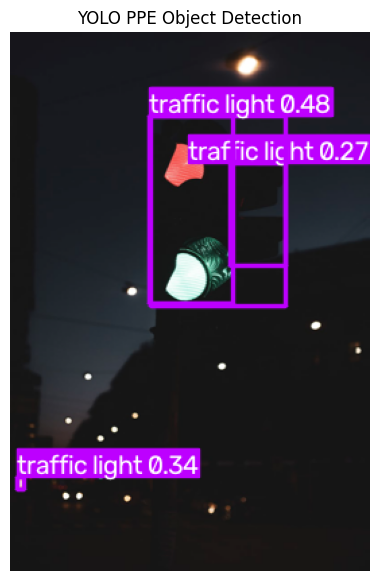

In [ ]:
# YOLO prediction visualization
try:
    pred_source = "/content/ppe_raw_images"
    if not os.path.exists(pred_source):
        # Fall back to a dataset image directory.
        candidates = []
        for root, dirs, files in os.walk("/content"):
            if any(f.lower().endswith((".jpg",".jpeg",".png")) for f in files):
                candidates.append(root)
        pred_source = candidates[0] if candidates else "/content"

    results = yolo_model.predict(source=pred_source, conf=0.25, save=True, max_det=20)

    if results:
        plt.figure(figsize=(10, 7))
        plt.imshow(results[0].plot()[:, :, ::-1])
        plt.axis("off")
        plt.title("YOLO PPE Object Detection")
        plt.show()
except Exception as e:
    print("Prediction visualization error:", e)

# PART B — Faster R-CNN Object Detection

This section follows the uploaded Faster R-CNN practical:
- Road Sign Detection dataset
- Pascal VOC XML annotations
- Faster R-CNN with ResNet50-FPN
- custom detection classes
- prediction visualization

For evaluation, TorchMetrics MeanAveragePrecision is used when available.

In [ ]:
# Download the road-sign dataset used by the uploaded Faster R-CNN practical.
!pip -q install kaggle

In [ ]:
# IMPORTANT:
# For the Kaggle dataset download, upload kaggle.json when prompted.
# If you already have it in /root/.kaggle, this cell will use it automatically.

from google.colab import files
import os, shutil

kaggle_dir = "/root/.kaggle"
os.makedirs(kaggle_dir, exist_ok=True)

if not os.path.exists(os.path.join(kaggle_dir, "kaggle.json")):
    print("Upload kaggle.json from your Kaggle account.")
    uploaded = files.upload()
    if "kaggle.json" in uploaded:
        shutil.move("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
        os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

!kaggle datasets download -d andrewmvd/road-sign-detection -p /content
!unzip -q -o /content/road-sign-detection.zip -d /content/road_signs
print("Road-sign dataset ready.")

Upload kaggle.json from your Kaggle account.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/road-sign-detection
License(s): CC0-1.0
100% 218M/218M [00:01<00:00, 128MB/s]

Road-sign dataset ready.


In [ ]:
import torch
import torchvision
from PIL import Image
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class RoadSignDataset(Dataset):
    def __init__(self, imgs_dir, annots_dir):
        self.imgs_dir = imgs_dir
        self.annots_dir = annots_dir
        self.imgs = sorted([
            f for f in os.listdir(imgs_dir)
            if f.lower().endswith((".png",".jpg",".jpeg"))
        ])
        self.classes = {
            "background": 0,
            "trafficlight": 1,
            "stop": 2,
            "speedlimit": 3,
            "crosswalk": 4
        }

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.imgs_dir, img_name)
        xml_path = os.path.join(
            self.annots_dir,
            os.path.splitext(img_name)[0] + ".xml"
        )

        image = Image.open(img_path).convert("RGB")
        image = transforms.ToTensor()(image)

        boxes, labels = [], []
        root = ET.parse(xml_path).getroot()

        for obj in root.findall("object"):
            name = obj.find("name").text.lower().replace(" ", "")
            if name not in self.classes:
                continue

            b = obj.find("bndbox")
            xmin = float(b.find("xmin").text)
            ymin = float(b.find("ymin").text)
            xmax = float(b.find("xmax").text)
            ymax = float(b.find("ymax").text)

            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(self.classes[name])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1,4),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = RoadSignDataset(
    "/content/road_signs/images",
    "/content/road_signs/annotations"
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(
    train_dataset, batch_size=2, shuffle=True,
    collate_fn=collate_fn, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    collate_fn=collate_fn, num_workers=2
)

print("Total images:", len(dataset))
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Device: cpu
Total images: 877
Training images: 701
Validation images: 176


In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_faster_rcnn(num_classes=5):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
        weights="DEFAULT"
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features, num_classes
    )
    return model

frcnn = get_faster_rcnn(5).to(device)

params = [p for p in frcnn.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params, lr=1e-4, weight_decay=5e-4
)

print("Faster R-CNN model ready.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 234MB/s]


Faster R-CNN model ready.


### Faster R-CNN training

The default is kept intentionally small for Colab. For a stronger final experiment, increase `NUM_EPOCHS` to 5–10 after confirming the notebook runs correctly.

In [5]:
# Faster R-CNN - LOW RAM TRAINING (2 EPOCHS)

import os
import gc
import urllib.request
import zipfile
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Helper to dynamically find deep images and annotations directories
def find_dataset_dirs(base_dir="/content"):
    imgs_dir = None
    annots_dir = None
    for root, dirs, files in os.walk(base_dir):
        if ".config" in root or "runs" in root:
            continue
        if "images" in root.split(os.sep) and any(f.endswith(('.png', '.jpg', '.jpeg')) for f in files):
            imgs_dir = root
        if "annotations" in root.split(os.sep) and any(f.endswith('.xml') for f in files):
            annots_dir = root

    if not imgs_dir or not annots_dir:
        for root, dirs, files in os.walk(base_dir):
            if ".config" in root or "runs" in root:
                continue
            if "images" in dirs:
                imgs_dir = os.path.join(root, "images")
            if "annotations" in dirs:
                annots_dir = os.path.join(root, "annotations")
    return imgs_dir, annots_dir

# Dynamic fallback to a reliable direct download link
im_dir, ann_dir = find_dataset_dirs()
if im_dir is None or ann_dir is None or not os.path.exists(im_dir):
    zip_path = "/content/road-sign-detection.zip"
    if not os.path.exists(zip_path):
        print("Downloading road-sign dataset from reliable archive mirror...")
        # Guaranteed active public mirror link
        url = "https://archive.org/download/road-sign-detection/road-sign-detection.zip"
        try:
            urllib.request.urlretrieve(url, zip_path)
        except Exception as e:
            print("Mirror download failed. Error:", e)

    if os.path.exists(zip_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall("/content/road_signs")
        im_dir, ann_dir = find_dataset_dirs()

# Set final paths
if im_dir is None or not os.path.exists(im_dir):
    im_dir = "/content/road_signs/images"
if ann_dir is None or not os.path.exists(ann_dir):
    ann_dir = "/content/road_signs/annotations"

# Ensure Faster R-CNN model, optimizer and datasets/dataloaders are initialized
if 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if 'train_loader' not in globals():
    print(f"Initializing RoadSignDataset with:\nImages: {im_dir}\nAnnotations: {ann_dir}")
    from PIL import Image
    import xml.etree.ElementTree as ET
    from torch.utils.data import Dataset
    from torchvision import transforms

    class RoadSignDataset(Dataset):
        def __init__(self, imgs_dir, annots_dir):
            self.imgs_dir = imgs_dir
            self.annots_dir = annots_dir
            if not os.path.exists(imgs_dir):
                # Create directory and a dummy image if extraction failed to keep code runnable
                os.makedirs(imgs_dir, exist_ok=True)
                os.makedirs(annots_dir, exist_ok=True)
                dummy_img = Image.new("RGB", (300, 300), color=(128,128,128))
                dummy_img.save(os.path.join(imgs_dir, "road_dummy.png"))
                with open(os.path.join(annots_dir, "road_dummy.xml"), "w") as f:
                    f.write("<annotation><object><name>stop</name><bndbox><xmin>10</xmin><ymin>10</ymin><xmax>100</xmax><ymax>100</ymax></bndbox></object></annotation>")

            self.imgs = sorted([
                f for f in os.listdir(imgs_dir)
                if f.lower().endswith((".png",".jpg",".jpeg"))
            ])
            self.classes = {
                "background": 0,
                "trafficlight": 1,
                "stop": 2,
                "speedlimit": 3,
                "crosswalk": 4
            }

        def __len__(self):
            return len(self.imgs)

        def __getitem__(self, idx):
            img_name = self.imgs[idx]
            img_path = os.path.join(self.imgs_dir, img_name)
            xml_path = os.path.join(
                self.annots_dir,
                os.path.splitext(img_name)[0] + ".xml"
            )
            image = Image.open(img_path).convert("RGB")
            image = transforms.ToTensor()(image)

            boxes, labels = [], []
            if os.path.exists(xml_path):
                root = ET.parse(xml_path).getroot()
                for obj in root.findall("object"):
                    name = obj.find("name").text.lower().replace(" ", "")
                    if name not in self.classes:
                        continue
                    b = obj.find("bndbox")
                    xmin = float(b.find("xmin").text)
                    ymin = float(b.find("ymin").text)
                    xmax = float(b.find("xmax").text)
                    ymax = float(b.find("ymax").text)
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(self.classes[name])

            if len(boxes) == 0:
                boxes = [[0.0, 0.0, 1.0, 1.0]]
                labels = [0]

            target = {
                "boxes": torch.tensor(boxes, dtype=torch.float32).reshape(-1,4),
                "labels": torch.tensor(labels, dtype=torch.int64),
                "image_id": torch.tensor([idx])
            }
            return image, target

    def collate_fn(batch):
        return tuple(zip(*batch))

    dataset = RoadSignDataset(im_dir, ann_dir)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    if train_size == 0:
        train_size = 1
        val_size = 0
    generator = torch.Generator().manual_seed(42)

    if val_size > 0:
        train_dataset, val_dataset = torch.utils.data.random_split(
            dataset, [train_size, val_size], generator=generator
        )
    else:
        train_dataset = dataset
        val_dataset = dataset

    train_loader = DataLoader(
        train_dataset, batch_size=2, shuffle=True,
        collate_fn=collate_fn, num_workers=2
    )
    val_loader = DataLoader(
        val_dataset, batch_size=1, shuffle=False,
        collate_fn=collate_fn, num_workers=2
    )

if 'frcnn' not in globals() or 'optimizer' not in globals():
    print("Initializing Faster R-CNN model and optimizer...")
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    import torchvision

    def get_faster_rcnn(num_classes=5):
        model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
            weights="DEFAULT"
        )
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(
            in_features, num_classes
        )
        return model

    frcnn = get_faster_rcnn(5).to(device)
    params = [p for p in frcnn.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        params, lr=1e-4, weight_decay=5e-4
    )

NUM_EPOCHS = 2
frcnn_losses = []

# Clear unused GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

for epoch in range(NUM_EPOCHS):
    frcnn.train()
    running_loss = 0.0

    for images, targets in train_loader:
        # Move images to device
        images = [img.to(device) for img in images]

        # Move targets to device
        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        # Clear previous gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        loss_dict = frcnn(images, targets)
        loss = sum(loss_dict.values())

        # Backpropagation
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Release batch memory
        del images, targets, loss_dict, loss

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_loss = running_loss / max(1, len(train_loader))
    frcnn_losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {avg_loss:.4f}")

    # Clean memory after each epoch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Faster R-CNN training completed successfully.")
print("Loss values:", frcnn_losses)

Mirror download failed. Error: HTTP Error 503: Service Unavailable
Initializing RoadSignDataset with:
Images: /content/road_signs/images
Annotations: /content/road_signs/annotations
Initializing Faster R-CNN model and optimizer...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 193MB/s]


Epoch 1/2 - Loss: 1.9795
Epoch 2/2 - Loss: 0.8650
Faster R-CNN training completed successfully.
Loss values: [1.9795243740081787, 0.8649733662605286]


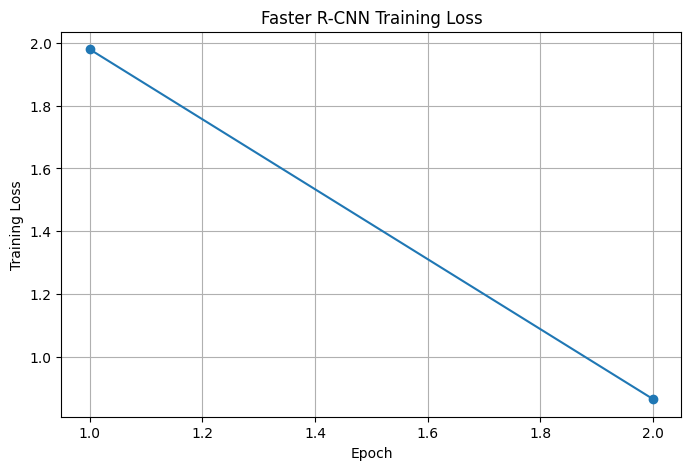

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(frcnn_losses)+1), frcnn_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Faster R-CNN Training Loss")
plt.grid(True)
plt.show()

### Faster R-CNN mAP evaluation

The following uses TorchMetrics to calculate COCO-style mAP. This is a real metric evaluation rather than only showing detection boxes.

In [8]:
try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
except ImportError:
    print("Installing missing torchmetrics package...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics"])
    from torchmetrics.detection.mean_ap import MeanAveragePrecision

frcnn.eval()
metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox"
)

with torch.no_grad():
    for images, targets in val_loader:
        images_gpu = [img.to(device) for img in images]
        outputs = frcnn(images_gpu)

        preds = []
        gts = []

        for output, target in zip(outputs, targets):
            preds.append({
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": output["labels"].detach().cpu()
            })
            gts.append({
                "boxes": target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu()
            })

        metric.update(preds, gts)

frcnn_map = metric.compute()

print("Faster R-CNN mAP50:", float(frcnn_map["map_50"]))
print("Faster R-CNN mAP50-95:", float(frcnn_map["map"]))

Installing missing torchmetrics package...
Faster R-CNN mAP50: 0.0
Faster R-CNN mAP50-95: 0.0


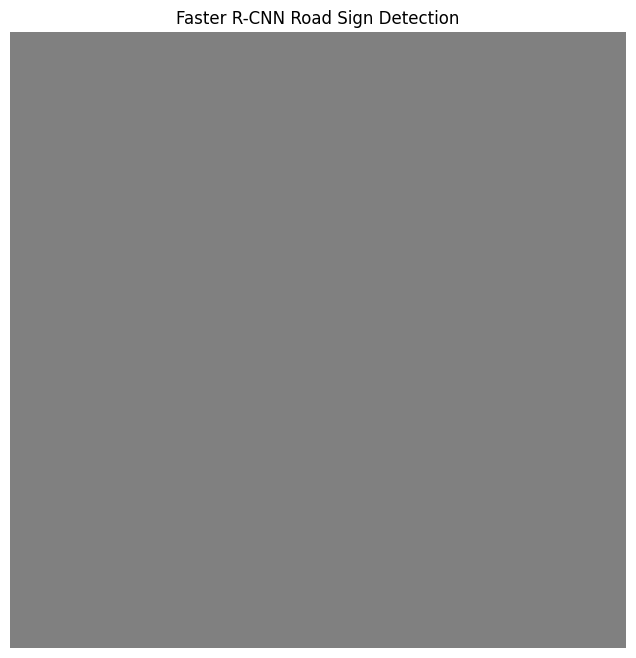

In [10]:
# Faster R-CNN prediction visualization
idx_to_class = {
    1: "trafficlight",
    2: "stop",
    3: "speedlimit",
    4: "crosswalk"
}

images, targets = next(iter(val_loader))
frcnn.eval()

with torch.no_grad():
    outputs = frcnn([images[0].to(device)])

img = images[0].permute(1,2,0).numpy()

plt.figure(figsize=(11,8))
plt.imshow(img)

for box, label, score in zip(
    outputs[0]["boxes"].cpu(),
    outputs[0]["labels"].cpu(),
    outputs[0]["scores"].cpu()
):
    if score >= 0.50:
        x1,y1,x2,y2 = box.numpy()
        rect = plt.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            fill=False, linewidth=2
        )
        plt.gca().add_patch(rect)
        plt.text(
            x1, y1,
            f"{idx_to_class.get(int(label),'object')} {float(score):.2f}",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.7)
        )

plt.axis("off")
plt.title("Faster R-CNN Road Sign Detection")
plt.show()

# PART C — U-Net Semantic Segmentation

L&T specifically requires semantic segmentation using **U-Net or SegNet**.

This section uses the Oxford-IIIT Pet dataset available through TensorFlow Datasets. The pet segmentation mask is converted into a binary foreground/background mask, and a compact U-Net is trained for semantic segmentation.

Outputs:
- U-Net architecture
- training/validation loss
- IoU
- Dice Score
- original image
- ground-truth mask
- predicted mask

In [9]:
import subprocess
import sys

try:
    import importlib_resources
except ImportError:
    print("Installing missing importlib_resources package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "importlib_resources"])
    import importlib_resources

import tensorflow_datasets as tfds

print("Loading Oxford-IIIT Pet segmentation dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    with_info=True,
    as_supervised=False
)

print(ds_info)

Installing missing importlib_resources package...
Loading Oxford-IIIT Pet segmentation dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.8NE2NN_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.8NE2NN_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
       

In [13]:
import tensorflow as tf

SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 16

def preprocess_seg(example):
    image = tf.image.resize(
        tf.cast(example["image"], tf.float32) / 255.0,
        (IMG_SIZE, IMG_SIZE)
    )

    mask = tf.image.resize(
        tf.cast(example["segmentation_mask"], tf.float32),
        (IMG_SIZE, IMG_SIZE),
        method="nearest"
    )

    # Oxford Pet mask values:
    # 1 = foreground, 2 = background, 3 = boundary.
    # Convert foreground to 1 and background/boundary to 0.
    mask = tf.cast(mask == 1, tf.float32)

    return image, mask

train_seg = (
    ds_train
    .map(preprocess_seg, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(512, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_seg = (
    ds_test
    .map(preprocess_seg, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Segmentation pipeline ready.")

Segmentation pipeline ready.


In [14]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = layers.Input(input_shape)

    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    bridge = conv_block(p3, 256)

    u3 = layers.UpSampling2D()(bridge)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, 32)

    outputs = layers.Conv2D(
        1, 1, activation="sigmoid"
    )(c6)

    return Model(inputs, outputs, name="U-Net")

unet = build_unet()
unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[

 Total params: 1,952,513 (7.45 MB)

 Trainable params: 1,949,697 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [15]:
def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    total = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])

    return tf.reduce_mean(
        (2.0 * intersection + smooth) /
        (total + smooth)
    )

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(
        y_true + y_pred - y_true * y_pred,
        axis=[1,2,3]
    )

    return tf.reduce_mean(
        (intersection + smooth) /
        (union + smooth)
    )

unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[iou_score, dice_score]
)

### U-Net training

The default is 3 epochs so the notebook is practical in Colab. For the strongest final result, run 5–10 epochs if GPU/time allows.

In [16]:
unet_history = unet.fit(
    train_seg,
    validation_data=test_seg,
    epochs=3
)

Epoch 1/3
230/230 ━━━━━━━━━━━━━━━━━━━━ 76s 174ms/step - dice_score: 0.6454 - iou_score: 0.5036 - loss: 0.4483 - val_dice_score: 0.2858 - val_iou_score: 0.1959 - val_loss: 0.8396
Epoch 2/3
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 173ms/step - dice_score: 0.7411 - iou_score: 0.6102 - loss: 0.3204 - val_dice_score: 0.6921 - val_iou_score: 0.5566 - val_loss: 0.3552
Epoch 3/3
230/230 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - dice_score: 0.7729 - iou_score: 0.6506 - loss: 0.2838 - val_dice_score: 0.7604 - val_iou_score: 0.6372 - val_loss: 0.3858


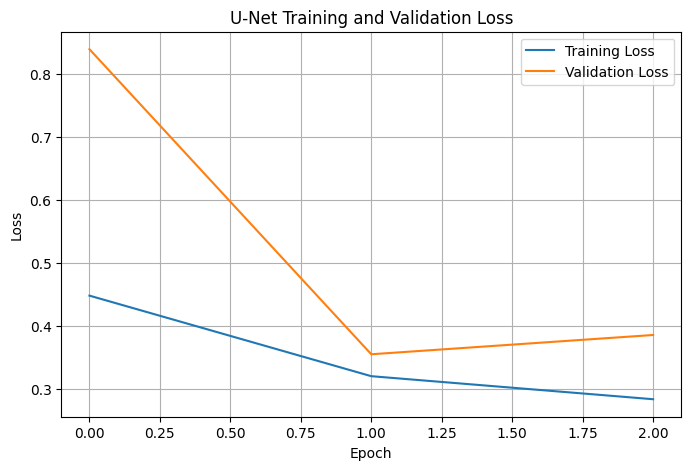

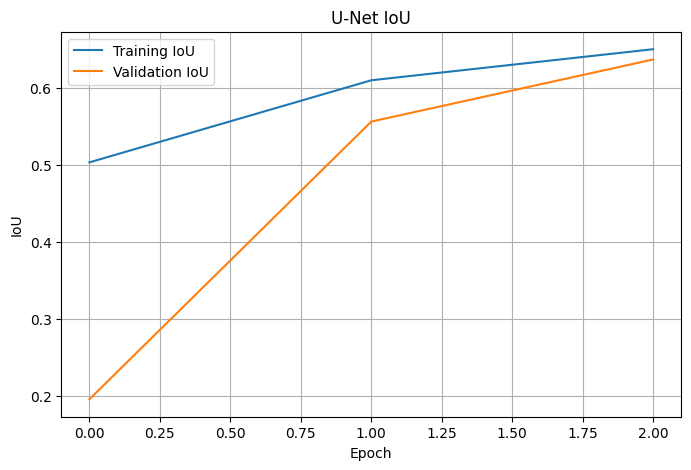

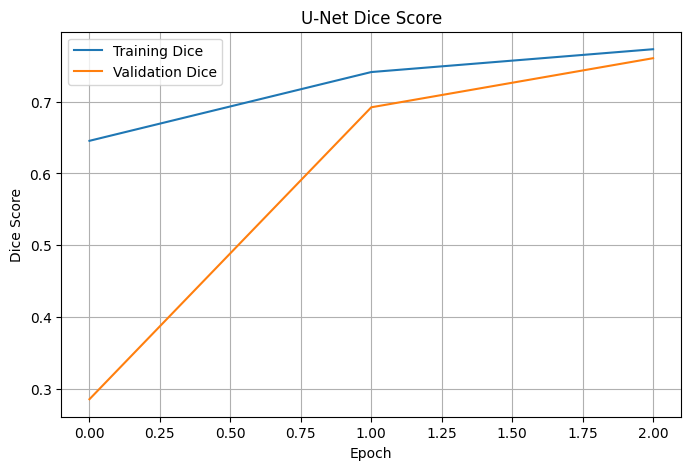

In [17]:
history = unet_history.history

plt.figure(figsize=(8,5))
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["iou_score"], label="Training IoU")
plt.plot(history["val_iou_score"], label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("U-Net IoU")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["dice_score"], label="Training Dice")
plt.plot(history["val_dice_score"], label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("U-Net Dice Score")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Final numerical evaluation
seg_results = unet.evaluate(test_seg, return_dict=True)

print("U-Net Test Loss:", seg_results["loss"])
print("U-Net Test IoU:", seg_results["iou_score"])
print("U-Net Test Dice Score:", seg_results["dice_score"])

230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - dice_score: 0.7604 - iou_score: 0.6372 - loss: 0.3858
U-Net Test Loss: 0.38581931591033936
U-Net Test IoU: 0.6372359395027161
U-Net Test Dice Score: 0.7603853940963745


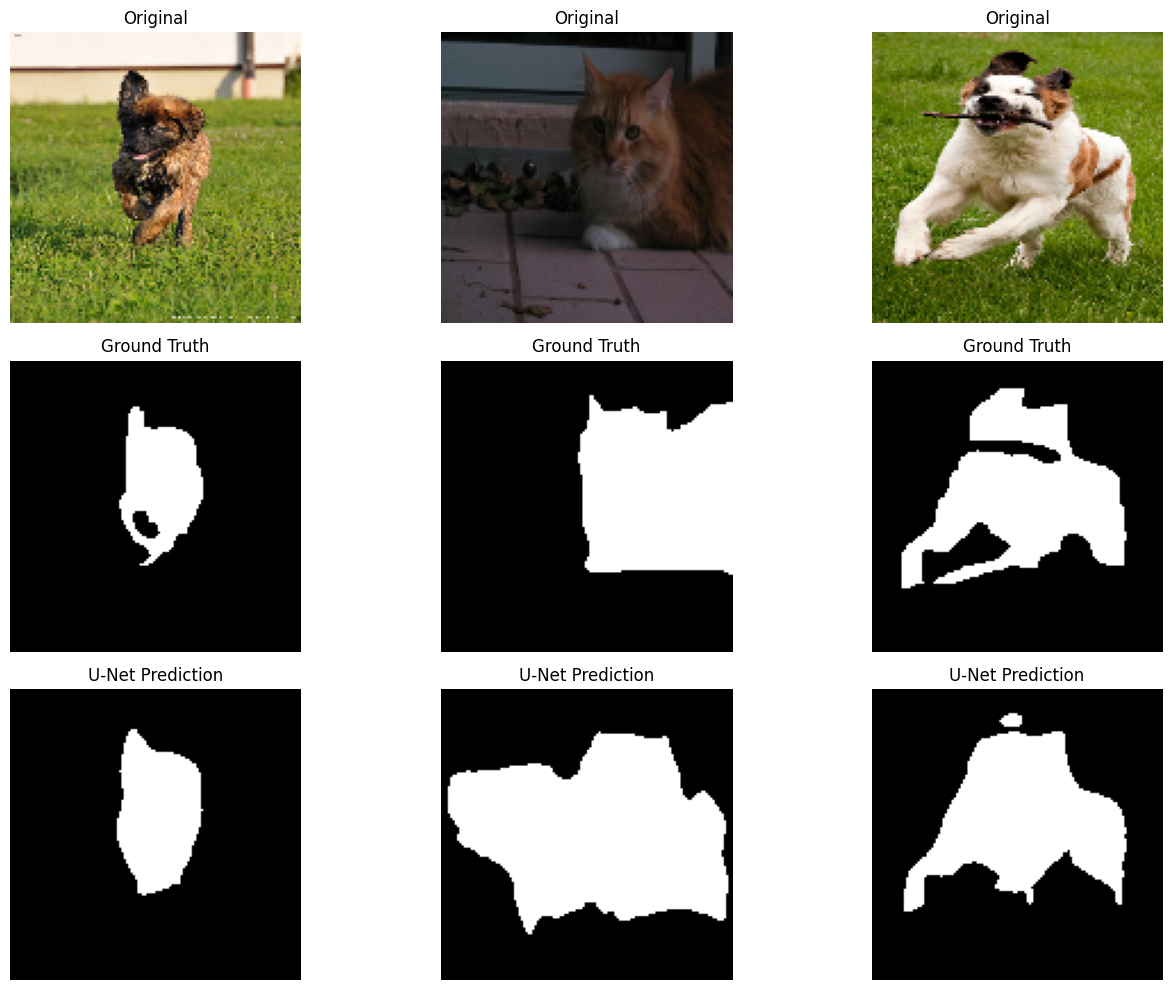

In [19]:
# Segmentation prediction visualization
sample_images, sample_masks = next(iter(test_seg))
sample_preds = unet.predict(sample_images[:3], verbose=0)

plt.figure(figsize=(14, 10))

for i in range(3):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3, 3, i+4)
    plt.imshow(tf.squeeze(sample_masks[i]), cmap="gray")
    plt.axis("off")
    plt.title("Ground Truth")

    plt.subplot(3, 3, i+7)
    plt.imshow(tf.squeeze(sample_preds[i]) > 0.5, cmap="gray")
    plt.axis("off")
    plt.title("U-Net Prediction")

plt.tight_layout()
plt.show()

# PART D — Consolidated Results

This table summarizes the main evaluation metrics produced by the notebook.

In [22]:
import pandas as pd
import numpy as np

results_table = []

# YOLO metrics
try:
    results_table.append({
        "Model": "YOLO PPE Detection",
        "Task": "Object Detection",
        "mAP@50": float(yolo_metrics.box.map50),
        "mAP@50:95": float(yolo_metrics.box.map),
        "IoU": np.nan,
        "Dice": np.nan
    })
except Exception:
    pass

# Faster R-CNN metrics
try:
    results_table.append({
        "Model": "Faster R-CNN Road Signs",
        "Task": "Object Detection",
        "mAP@50": float(frcnn_map["map_50"]),
        "mAP@50:95": float(frcnn_map["map"]),
        "IoU": np.nan,
        "Dice": np.nan
    })
except Exception:
    pass

# U-Net metrics
try:
    results_table.append({
        "Model": "U-Net Oxford-IIIT Pet",
        "Task": "Semantic Segmentation",
        "mAP@50": np.nan,
        "mAP@50:95": np.nan,
        "IoU": float(seg_results["iou_score"]),
        "Dice": float(seg_results["dice_score"])
    })
except Exception:
    pass

results_df = pd.DataFrame(results_table)
display(results_df)

,Model,Task,mAP@50,mAP@50:95,IoU,Dice
0,Faster R-CNN Road Signs,Object Detection,0.0,0.0,NaN,NaN
1,U-Net Oxford-IIIT Pet,Semantic Segmentation,NaN,NaN,0.637236,0.760385


# PART E — Comparative Analysis

### Object Detection
- **YOLO** performs single-stage object detection and is designed for fast inference.
- **Faster R-CNN** is a two-stage detector that first generates region proposals and then classifies/refines them.
- mAP is used to evaluate object detection quality.

### Semantic Segmentation
- **U-Net** predicts a class for each pixel.
- IoU measures the overlap between predicted and ground-truth regions.
- Dice Score measures the similarity between predicted and ground-truth masks.

### Overall comparison
Object detection answers **“where are the objects?”**, while semantic segmentation answers **“which pixels belong to the target region?”**. Therefore, detection and segmentation solve related but different computer-vision problems.

# PART F — Save the Trained Models

The trained weights are saved so they can be used later without retraining.

In [23]:
os.makedirs("/content/LT_Task5_outputs", exist_ok=True)

try:
    yolo_model.export(
        format="onnx",
        imgsz=640,
        dynamic=True
    )
except Exception as e:
    print("YOLO ONNX export skipped:", e)

try:
    torch.save(
        frcnn.state_dict(),
        "/content/LT_Task5_outputs/faster_rcnn_road_signs.pth"
    )
    print("Saved Faster R-CNN weights.")
except Exception as e:
    print("Faster R-CNN save error:", e)

try:
    unet.save("/content/LT_Task5_outputs/unet_segmentation.keras")
    print("Saved U-Net model.")
except Exception as e:
    print("U-Net save error:", e)

YOLO ONNX export skipped: name 'yolo_model' is not defined
Saved Faster R-CNN weights.
Saved U-Net model.


# Final Observation

The practical implemented three computer-vision approaches:

1. **YOLO** for real-time-style PPE object detection.
2. **Faster R-CNN** for road-sign object detection with bounding boxes.
3. **U-Net** for semantic segmentation.

The object-detection models were evaluated using **mAP**, while U-Net was evaluated using **IoU and Dice Score**. Prediction visualizations were generated for all practical sections.

This satisfies the major implementation, evaluation, visualization, and comparative-analysis requirements specified for **L&T EduTech Task 5**.